In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
import numpy as np
import os
import glob
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

# Folder with all CSV-files
folder_path = "/content/drive/MyDrive/Total_net"

# Find all CSV files
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

# Read and unite CSV files
df_list = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)

# Save into 1 CSV-file
combined_df.to_csv('connected_file.csv', index=False)

# download file
df1 = pd.read_csv('connected_file.csv')

df1 = df1.iloc[1:]

# Working with first column (divide it into 2 columns with Date and Time)
df1['Date (GMT+1)'] = pd.to_datetime(df1['Date (GMT+1)'], utc=True)

df1['Date'] = df1['Date (GMT+1)'].dt.date       # Only date
df1['Time'] = df1['Date (GMT+1)'].dt.time       # Only Time

df1.drop(columns=['Date (GMT+1)'], inplace=True)
df1.drop(columns=['Solar'], inplace=True)



# Save
df1.to_csv('with_separated_time_and_date.csv', index=False)


print(len(df1))
df1.head()

Mounted at /content/drive


/tmp/ipython-input-2-1272626840.py:10: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in csv_files]
/tmp/ipython-input-2-1272626840.py:10: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in csv_files]
/tmp/ipython-input-2-1272626840.py:10: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in csv_files]
/tmp/ipython-input-2-1272626840.py:10: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in csv_files]
/tmp/ipython-input-2-1272626840.py:10: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,

187299


,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Load (incl. self-consumption),Nuclear,Date,Time
1,1526.9,4501.3,3336.8,2691.3,513.3,159.3,5017.1,23.8,108.6,453.1,1479.8,961.3,2415.1,32462.5,50971.8,NaN,2024-12-31,23:00:00
2,1540.1,4355.5,3350.9,2447.3,513.4,135.3,5000.2,23.8,160.7,838.4,1480.2,961,2601.3,32322.9,50048,NaN,2024-12-31,23:15:00
3,1539.7,4288.4,3347.5,2423.2,513.3,135.1,4952.9,23.8,75.1,435.4,1480.3,961.1,2542.3,32321.4,50088.8,NaN,2024-12-31,23:30:00
4,1567.1,4257.1,3379.6,2411.4,513.3,138,5019.7,23.9,58,105.9,1480,962.5,2450,32383.3,49955.6,NaN,2024-12-31,23:45:00
5,1542.2,4329.6,3930.2,2404.7,513.3,136,4799.9,24,58.5,367,1479.5,966.4,2252.6,32740,49695.9,NaN,2025-01-01,00:00:00


In [ ]:

# Folder with all CSV-files
folder_path2 = "/content/drive/MyDrive/Forecast"

# Find all CSV files
csv_files2 = glob.glob(os.path.join(folder_path2, '*.csv'))

# Read and unite CSV files
df_list2 = [pd.read_csv(file) for file in csv_files2]
combined_df2 = pd.concat(df_list2, ignore_index=True)

# Save into 1 CSV-file
combined_df2.to_csv('connected_file2.csv', index=False)

# download file
df2 = pd.read_csv('connected_file2.csv')

df2 = df2.iloc[1:187300]

# Working with first column (we don't need it here)
df2.drop(columns=['Date (GMT+1)'], inplace=True)

# Save
df2.to_csv('with_separated_time_and_date2.csv', index=False)


print(len(df2))
df2.head()

/tmp/ipython-input-3-395015767.py:15: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('connected_file2.csv')


187299


,Solar,"Solar forecast (Day-Ahead, D-1 18:00)","Solar forecast (Intraday, 8:00)",Solar forecast (Current)
1,9.9,0,0,0
2,9.3,0,0,0
3,9.3,0,0,0
4,9.5,0,0,0
5,9.9,0,0,0


In [ ]:

final_df = pd.concat([df1, df2], axis=1)
final_df.to_csv('connected_by_columns.csv', index=False)
final_df.head()

# Delete two columns where we don't have enough information
final_df.drop(columns=['Solar forecast (Current)', 'Fossil coal-derived gas', 'Solar forecast (Intraday, 8:00)'], inplace=True)
final_df.head()
final_df = final_df[~final_df.isin(['Power (MW)']).any(axis=1)]

# Germany doesn't have Nuclear energy
final_df.drop(columns=['Nuclear'], inplace=True)

In [ ]:
# We don't need offshore and onshore, just summ it
final_df['Wind offshore'] = pd.to_numeric(final_df['Wind offshore'], errors='coerce')
final_df['Wind onshore'] = pd.to_numeric(final_df['Wind onshore'], errors='coerce')

final_df['Wind'] = final_df['Wind offshore'] + final_df['Wind onshore']
final_df.drop(columns=['Wind offshore','Wind onshore','Solar forecast (Day-Ahead, D-1 18:00)'], inplace=True)
final_df.head()

,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Load (incl. self-consumption),Date,Time,Solar,Wind
1,1526.9,4501.3,3336.8,2691.3,513.3,5017.1,23.8,108.6,453.1,1479.8,961.3,50971.8,2024-12-31,23:00:00,9.9,34877.6
2,1540.1,4355.5,3350.9,2447.3,513.4,5000.2,23.8,160.7,838.4,1480.2,961,50048,2024-12-31,23:15:00,9.3,34924.2
3,1539.7,4288.4,3347.5,2423.2,513.3,4952.9,23.8,75.1,435.4,1480.3,961.1,50088.8,2024-12-31,23:30:00,9.3,34863.7
4,1567.1,4257.1,3379.6,2411.4,513.3,5019.7,23.9,58,105.9,1480,962.5,49955.6,2024-12-31,23:45:00,9.5,34833.3
5,1542.2,4329.6,3930.2,2404.7,513.3,4799.9,24,58.5,367,1479.5,966.4,49695.9,2025-01-01,00:00:00,9.9,34992.6


In [ ]:
#check for NaN values

print(final_df.isna().mean() * 100)
df_clean = final_df.dropna(subset=['Load (incl. self-consumption)'])

Hydro Run-of-River               0.000000
Biomass                          0.000000
Fossil brown coal / lignite      0.000000
Fossil hard coal                 0.000000
Fossil oil                       0.000000
Fossil gas                       0.000000
Geothermal                       0.000000
Hydro water reservoir            0.000000
Hydro pumped storage             0.000000
Others                           0.000000
Waste                            0.000000
Load (incl. self-consumption)    0.000534
Date                             0.000000
Time                             0.000000
Solar                            0.049656
Wind                             0.000000
dtype: float64


In [ ]:
#dropping Nan values
df_clean = df_clean.dropna()
print(df_clean.isna().mean() * 100)

Hydro Run-of-River               0.0
Biomass                          0.0
Fossil brown coal / lignite      0.0
Fossil hard coal                 0.0
Fossil oil                       0.0
Fossil gas                       0.0
Geothermal                       0.0
Hydro water reservoir            0.0
Hydro pumped storage             0.0
Others                           0.0
Waste                            0.0
Load (incl. self-consumption)    0.0
Date                             0.0
Time                             0.0
Solar                            0.0
Wind                             0.0
dtype: float64


In [ ]:

# make a copy
dfd = df_clean.copy()

# Making new index (DateTime format) and converting 'Load' column into numerical type ===
dfd['Datetime'] = pd.to_datetime(dfd['Date'].astype(str) + ' ' + dfd['Time'].astype(str))
dfd.set_index('Datetime', inplace=True)
dfd.sort_index(inplace=True)
dfd['Load (incl. self-consumption)'] = pd.to_numeric(dfd['Load (incl. self-consumption)'], errors='coerce')
dfd = dfd.drop(columns=['Date', 'Time'])  # delete old rows
for col in dfd.columns:
    dfd[col] = pd.to_numeric(dfd[col], errors='coerce')
dfd

,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Load (incl. self-consumption),Solar,Wind
Datetime,,,,,,,,,,,,,,
2019-12-31 23:00:00,1591.9,5396.8,9410.0,2200.5,503.8,9408.1,27.9,451.2,1026.3,1630.5,1399.9,47213.4,4.9,6410.4
2019-12-31 23:15:00,1586.9,5390.0,9434.5,2159.4,503.9,9209.9,27.9,385.7,628.8,1609.6,1409.5,46952.8,4.7,6407.3
2019-12-31 23:30:00,1581.2,5372.1,9467.0,2153.1,503.9,9069.3,27.9,274.5,528.6,1609.2,1416.4,46620.7,4.5,6649.0
2019-12-31 23:45:00,1581.3,5372.3,9479.7,2186.7,503.9,8956.1,27.8,98.7,312.0,1609.5,1408.1,46425.5,4.6,6896.0
2020-01-01 00:00:00,1581.8,5369.3,9540.4,2145.8,503.9,8659.5,27.9,244.1,723.0,1609.3,1385.0,46283.2,4.5,6985.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-04 21:00:00,1684.6,4534.7,7411.2,1109.6,331.8,4555.1,15.1,260.0,772.0,1083.6,894.8,44676.6,0.0,10876.0
2025-05-04 21:15:00,1666.2,4526.7,7232.7,1029.7,331.8,4540.2,15.1,127.0,507.0,1083.6,889.3,43930.1,0.0,11291.0
2025-05-04 21:30:00,1666.2,4521.0,7272.7,981.7,331.8,4507.2,15.1,87.0,213.0,1083.6,883.9,43159.4,0.0,11757.0


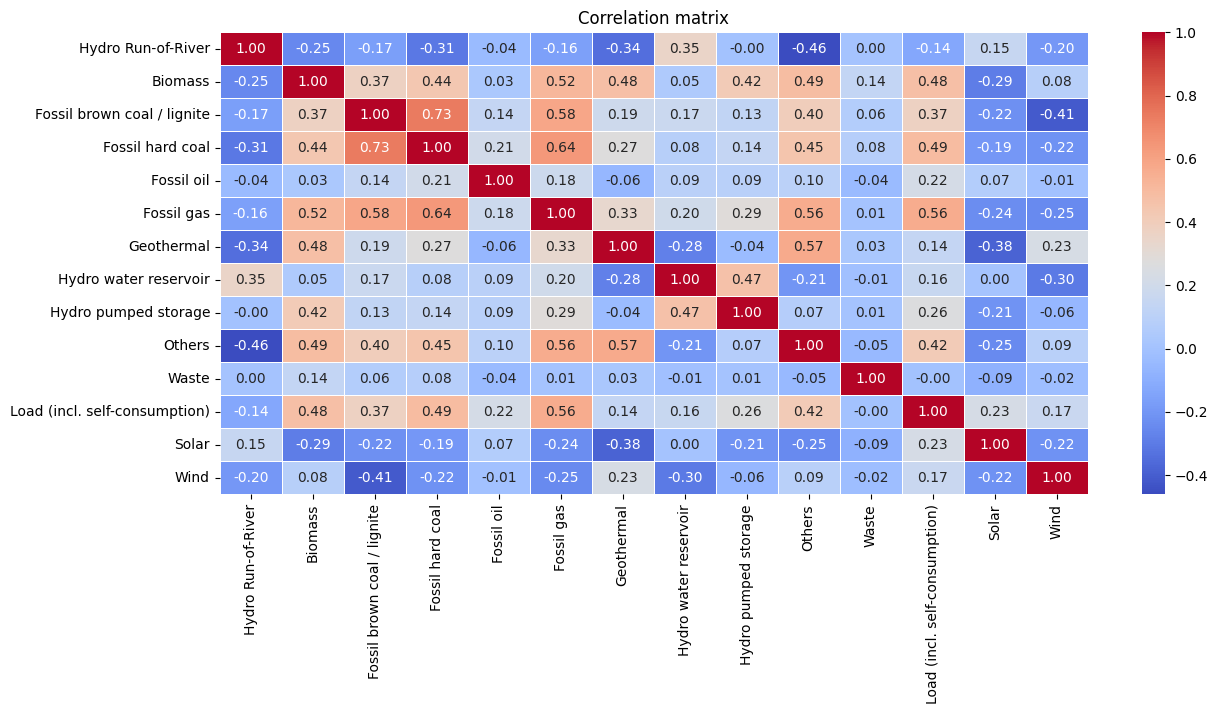

In [ ]:
# We have too many variables, check which are correlated

corr = dfd.corr()

plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix')
plt.show()

In [ ]:
selected_features = [
    'Fossil gas',
    'Biomass',
    'Fossil brown coal / lignite',
    'Fossil hard coal',
    'Hydro pumped storage',
    'Others',
    'Solar',
    'Fossil oil'
]

In [ ]:
data = dfd.copy()
data.index = pd.to_datetime(data.index)

data['year'] = data.index.year
data['month'] = data.index.month
data['weekday'] = data.index.weekday
data['hour'] = data.index.hour
data = data.reset_index(drop=True)

In [ ]:
data

,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Load (incl. self-consumption),Solar,Wind,year,month,weekday,hour
0,1591.9,5396.8,9410.0,2200.5,503.8,9408.1,27.9,451.2,1026.3,1630.5,1399.9,47213.4,4.9,6410.4,2019,12,1,23
1,1586.9,5390.0,9434.5,2159.4,503.9,9209.9,27.9,385.7,628.8,1609.6,1409.5,46952.8,4.7,6407.3,2019,12,1,23
2,1581.2,5372.1,9467.0,2153.1,503.9,9069.3,27.9,274.5,528.6,1609.2,1416.4,46620.7,4.5,6649.0,2019,12,1,23
3,1581.3,5372.3,9479.7,2186.7,503.9,8956.1,27.8,98.7,312.0,1609.5,1408.1,46425.5,4.6,6896.0,2019,12,1,23
4,1581.8,5369.3,9540.4,2145.8,503.9,8659.5,27.9,244.1,723.0,1609.3,1385.0,46283.2,4.5,6985.2,2020,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187190,1684.6,4534.7,7411.2,1109.6,331.8,4555.1,15.1,260.0,772.0,1083.6,894.8,44676.6,0.0,10876.0,2025,5,6,21
187191,1666.2,4526.7,7232.7,1029.7,331.8,4540.2,15.1,127.0,507.0,1083.6,889.3,43930.1,0.0,11291.0,2025,5,6,21
187192,1666.2,4521.0,7272.7,981.7,331.8,4507.2,15.1,87.0,213.0,1083.6,883.9,43159.4,0.0,11757.0,2025,5,6,21
187193,1670.8,4514.2,6999.9,973.7,331.8,4415.6,15.1,80.0,128.0,1083.6,883.9,42970.9,0.0,12009.0,2025,5,6,21


In [ ]:
for lag in [1, 4, 96]:
    data[f'Load_lag_{lag}'] = data['Load (incl. self-consumption)'].shift(lag)

data=data.dropna()

In [ ]:
data.columns

Index(['Hydro Run-of-River', 'Biomass', 'Fossil brown coal / lignite',
       'Fossil hard coal', 'Fossil oil', 'Fossil gas', 'Geothermal',
       'Hydro water reservoir', 'Hydro pumped storage', 'Others', 'Waste',
       'Load (incl. self-consumption)', 'Solar', 'Wind', 'year', 'month',
       'weekday', 'hour', 'Load_lag_1', 'Load_lag_4', 'Load_lag_96'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
# Applying the default XGBoost model

# Create objects X and y
X = data[[
    'Fossil gas',
    'Biomass',
    'Fossil brown coal / lignite',
    'Fossil hard coal',
    'Hydro pumped storage',
    'Others',
    'Solar',
    'Fossil oil',
    'year',
    'month',
    'weekday',
    'hour',
    'Load_lag_1',
    'Load_lag_4',
    'Load_lag_96'
]]

X=X.dropna()
y = data['Load (incl. self-consumption)']

horizon = 96  # 1 week with 15-minutes intervals

# Create multi-output y (each row is a forecast for t+1 through t+672)
y_multi = np.column_stack([
    data['Load (incl. self-consumption)'].shift(-i) for i in range(1, horizon + 1)
])

# final X and y
X_final = X.iloc[:-horizon].copy()
y_final = y_multi[:-horizon]


# First split train/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_final, y_final, test_size=0.1, random_state=12345, shuffle=False)

# Then split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.33, random_state=42, shuffle=False)

In [ ]:
naive_preds = np.column_stack([
    X_test['Load_lag_1'].values for _ in range(y_test.shape[1])
])

# Теперь считаем метрики для сравнения
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_naive = r2_score(y_test, naive_preds)
rmse_naive = mean_squared_error(y_test, naive_preds)
mae_naive = mean_absolute_error(y_test, naive_preds)

print(f"Naive Forecast - R²: {r2_naive:.4f}, RMSE: {rmse_naive:.2f}, MAE: {mae_naive:.2f}")

Naive Forecast - R²: -0.1783, RMSE: 112078081.68, MAE: 8346.44


# XGB

In [ ]:
pip install --upgrade xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.7 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4


In [ ]:
from joblib import Parallel, delayed
from sklearn.base import clone
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from tqdm import tqdm
import time

In [ ]:
from joblib import Parallel, delayed
from sklearn.base import clone
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from tqdm import tqdm
import time

base_model = XGBRegressor(
    random_state=42,
    n_jobs=1,
    verbosity=0
)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.05],
    'max_depth': [4, 6, 8, 10],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
}

# Randomized Search с логированием времени
print("=== Start RandomizedSearchCV ===")
start_search = time.time()

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=25,  # можно начать с 20
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)



random_search.fit(X_train, y_train[:, 0])

end_search = time.time()
print(f"=== RandomizedSearchCV complete in {(end_search - start_search)/60:.2f} min ===")


best_params = random_search.best_params_
print("Best hyperparameters:", best_params)

=== Start RandomizedSearchCV ===
Fitting 3 folds for each of 25 candidates, totalling 75 fits
=== RandomizedSearchCV complete in 5.96 min ===
Best hyperparameters: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 1.0}


In [ ]:
# Creating base model
final_model = XGBRegressor(
    random_state=42,
    n_jobs=1,
    verbosity=0,
    **best_params
)

# Function to train one model
def train_one(i):
    model = clone(final_model)
    model.fit(X_train, y_train[:, i])
    return model

# Parallel training
models = Parallel(n_jobs=-1)(
    delayed(train_one)(i) for i in tqdm(range(y_train.shape[1]), desc="Training XGB")
)

Training XGB: 100%|██████████| 96/96 [15:05<00:00,  9.44s/it]


In [ ]:
# Save model
for i, model in enumerate(models):
    model.save_model(f"xgb_model_RS{i}.json")

In [ ]:
# # Download 1 model
# from xgboost import XGBRegressor

# model = XGBRegressor()
# model.load_model("xgb_model_RS0.json")

In [ ]:
from xgboost import XGBRegressor

# Download all models
models = []
for i in range(y_test.shape[1]):  # предполагаю что у тебя 96 горизонтов
    model = XGBRegressor()
    model.load_model(f"xgb_model_RS{i}.json")
    models.append(model)


In [ ]:
# Predict for all models
y_pred = np.column_stack([
    model.predict(X_test)
    for model in models
])

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

r2_list = []
rmse_list = []
mae_list = []

for i in range(y_test.shape[1]):
    y_true = y_test[:, i]
    y_hat = y_pred[:, i]

    r2 = r2_score(y_true, y_hat)
    rmse = mean_squared_error(y_true, y_hat)
    mae = mean_absolute_error(y_true, y_hat)

    r2_list.append(r2)
    rmse_list.append(rmse)
    mae_list.append(mae)

# Pivot table
metrics_df = pd.DataFrame({
    'horizon': np.arange(1, y_test.shape[1] + 1),
    'R2': r2_list,
    'RMSE': rmse_list,
    'MAE': mae_list
})

print(metrics_df.tail(10))


    horizon        R2          RMSE          MAE
86       87  0.889509  1.052170e+07  2358.516847
87       88  0.894300  1.006482e+07  2312.295374
88       89  0.898975  9.619324e+06  2231.038021
89       90  0.904771  9.067116e+06  2167.791280
90       91  0.903441  9.193635e+06  2168.011247
91       92  0.905632  8.984983e+06  2164.504399
92       93  0.904175  9.123838e+06  2164.590995
93       94  0.900877  9.438249e+06  2191.221329
94       95  0.902441  9.289730e+06  2184.902229
95       96  0.903143  9.223494e+06  2178.736243


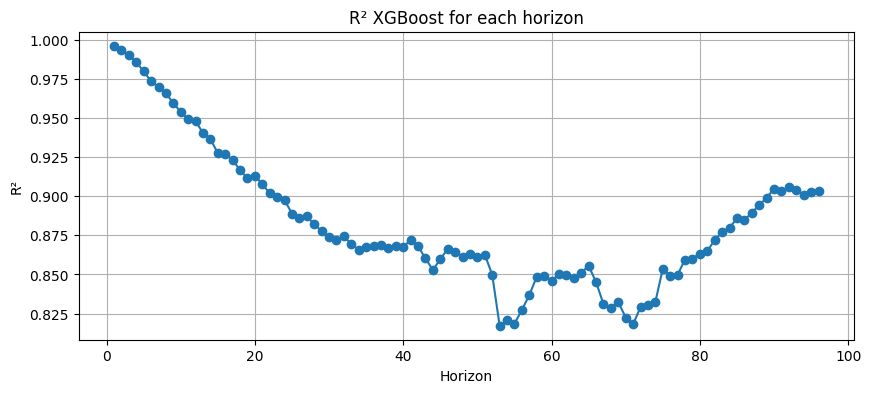

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['R2'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('R²')
plt.title('R² XGBoost for each horizon')
plt.grid()
plt.show()

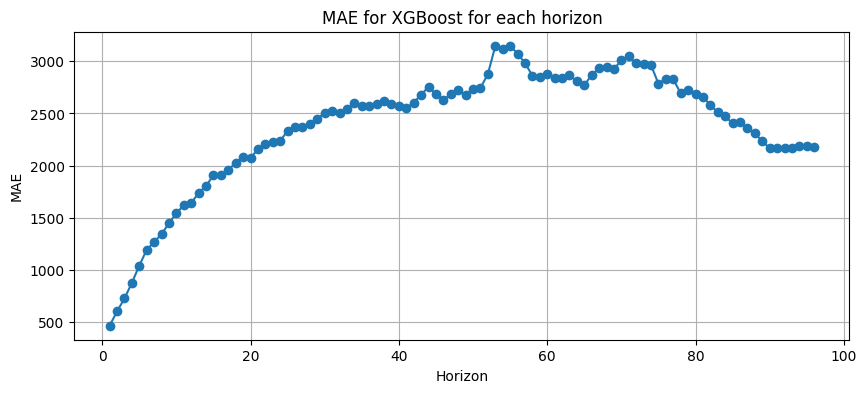

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['MAE'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('MAE')
plt.title('MAE for XGBoost for each horizon')
plt.grid()
plt.show()

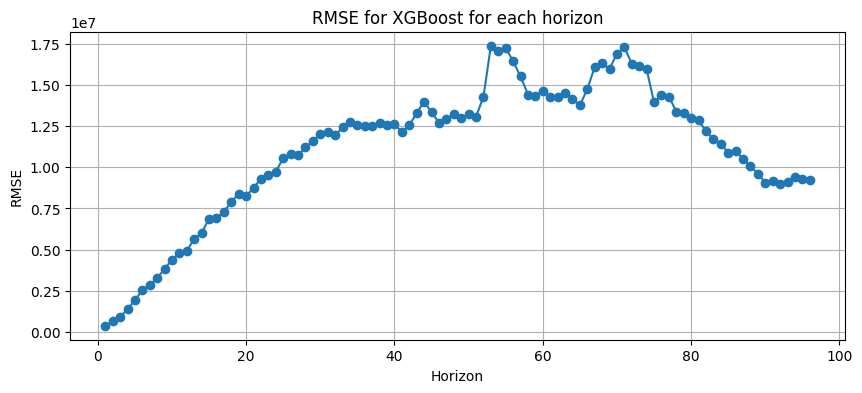

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['RMSE'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('RMSE')
plt.title('RMSE for XGBoost for each horizon')
plt.grid()
plt.show()

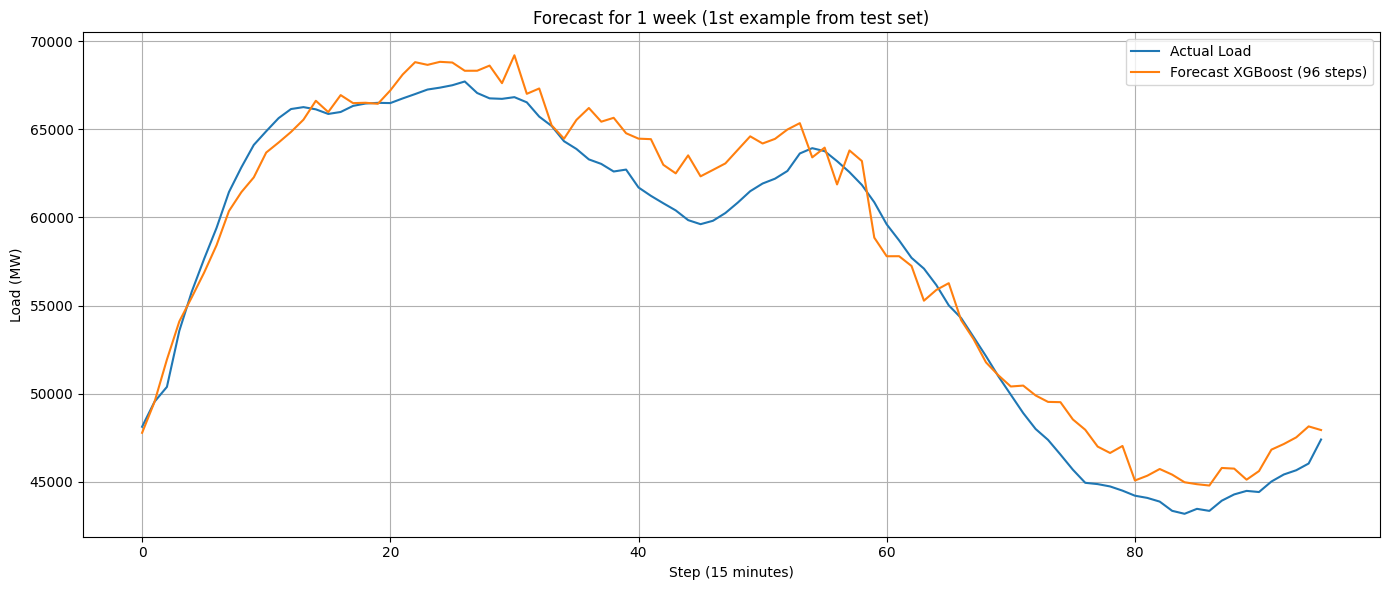

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 6))
# plt.plot(y_test[:min_len][0], label='Actual Load')
# plt.plot(y_pred[:min_len][0], label='Forecast XGBoost (96 steps)')
# plt.title('Forecast for 1 day (1st example from test set)')
# plt.xlabel('Step (15 minutes)')
# plt.ylabel('Load (MW)')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

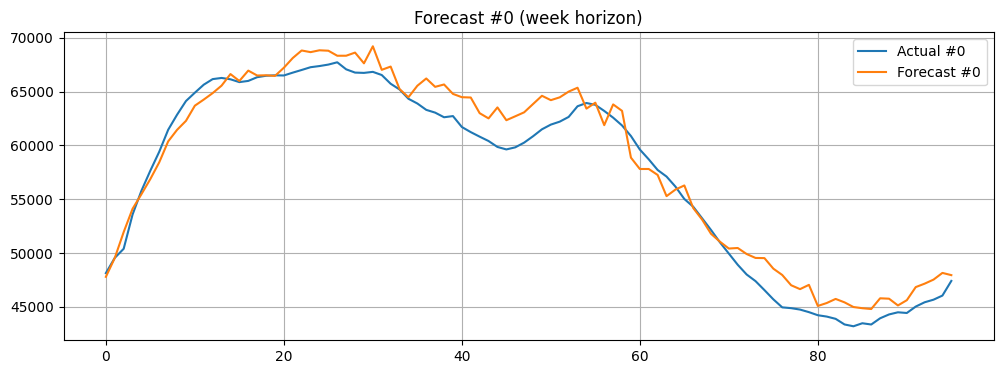

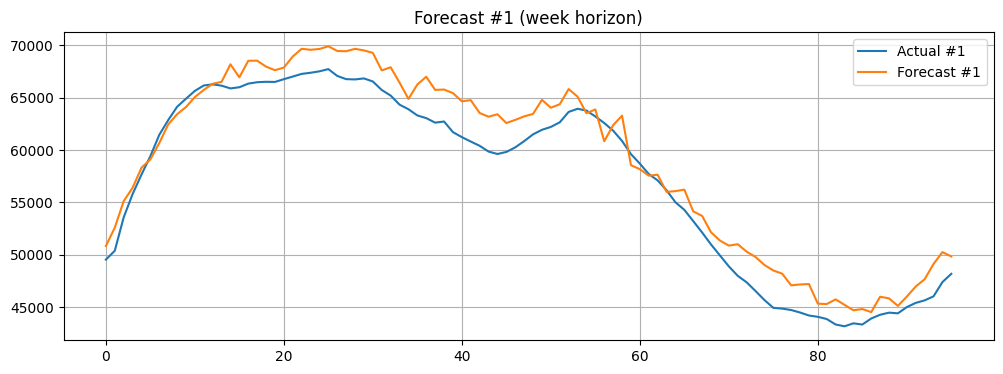

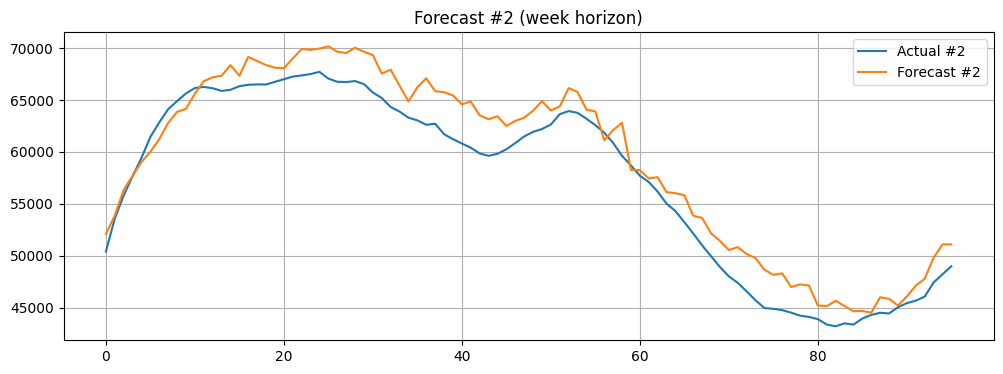

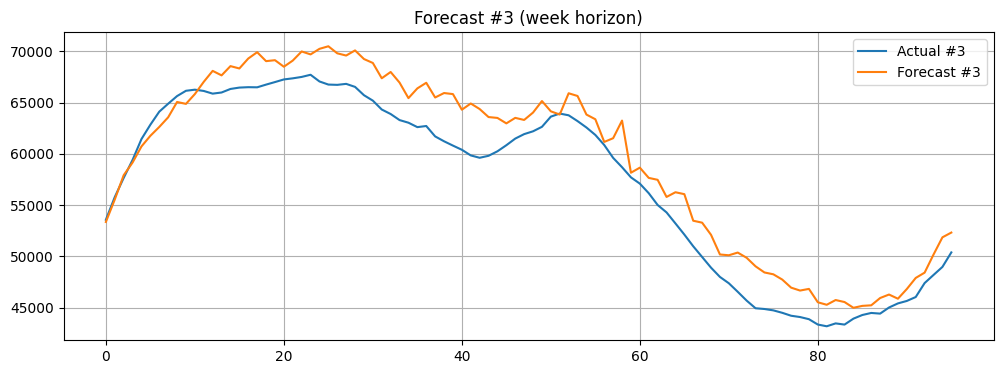

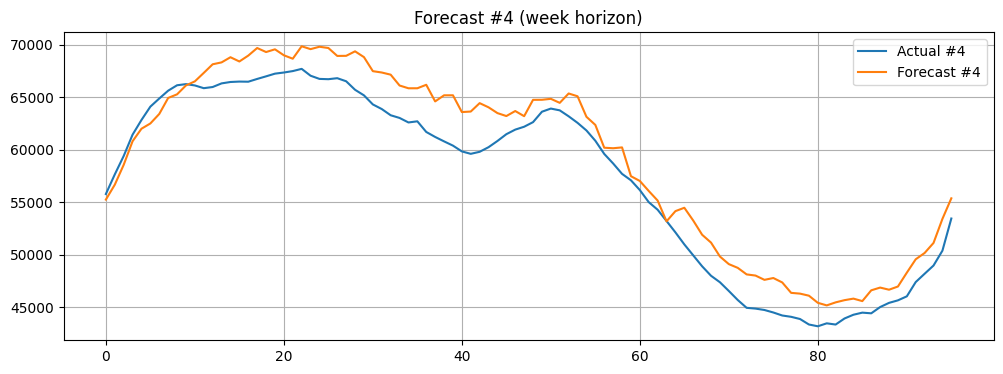

In [ ]:
# for i in range(5):
#     plt.figure(figsize=(12, 4))
#     plt.plot(y_test[i], label=f'Actual #{i}')
#     plt.plot(y_pred[i], label=f'Forecast #{i}')
#     plt.title(f'Forecast #{i} (day horizon)')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# LGBM

In [ ]:
!pip install --upgrade tqdm

In [ ]:
from joblib import Parallel, delayed
from sklearn.base import clone
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from tqdm import tqdm
import time

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.05],
    'max_depth': [4, 6, 8, 10, -1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [0, 0.1, 1, 5],
}


base_model = LGBMRegressor(
    learning_rate=0.05,
    random_state=42,
    n_jobs=1,
    verbose=-1
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)



random_search.fit(X_train, y_train[:, 0])

best_params = random_search.best_params_
print("Best hyperparameters:", best_params)



Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [ ]:
final_model = LGBMRegressor(
    random_state=42,
    n_jobs=1,
    verbose=-1,
    **best_params
)

def train_one(i):
    model = clone(final_model)
    model.fit(X_train, y_train[:, i])
    return model


from joblib import Parallel, delayed
from tqdm import tqdm

models = Parallel(n_jobs=-1)(
    delayed(train_one)(i) for i in tqdm(range(y_train.shape[1]), desc="Training LGBM")
)

Training LGBM: 100%|██████████| 96/96 [08:21<00:00,  5.22s/it]


In [ ]:
for i, model in enumerate(models):
    booster = model.booster_
    booster.save_model(f"lgbm_model_RS{i}.txt")

In [ ]:
from lightgbm import Booster


models = []
for i in range(y_test.shape[1]):
    booster = Booster(model_file=f"lgbm_model_RS{i}.txt")
    models.append(booster)

In [ ]:
import numpy as np


y_pred = np.column_stack([
    model.predict(X_test)
    for model in models
])

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

r2_list = []
rmse_list = []
mae_list = []

for i in range(y_test.shape[1]):
    y_true = y_test[:, i]
    y_hat = y_pred[:, i]

    r2 = r2_score(y_true, y_hat)
    rmse = mean_squared_error(y_true, y_hat)  # RMSE
    mae = mean_absolute_error(y_true, y_hat)

    r2_list.append(r2)
    rmse_list.append(rmse)
    mae_list.append(mae)


metrics_df = pd.DataFrame({
    'horizon': np.arange(1, y_test.shape[1] + 1),
    'R2': r2_list,
    'RMSE': rmse_list,
    'MAE': mae_list
})

print(metrics_df.tail(10))

    horizon        R2          RMSE          MAE
86       87  0.894203  1.007465e+07  2299.726435
87       88  0.895259  9.973528e+06  2276.540899
88       89  0.904329  9.109489e+06  2166.440290
89       90  0.906060  8.944452e+06  2147.253883
90       91  0.908702  8.692742e+06  2130.375241
91       92  0.906623  8.890601e+06  2153.146197
92       93  0.903920  9.148166e+06  2179.303090
93       94  0.898059  9.706512e+06  2226.192129
94       95  0.901360  9.392610e+06  2193.938667
95       96  0.904681  9.077017e+06  2179.191865


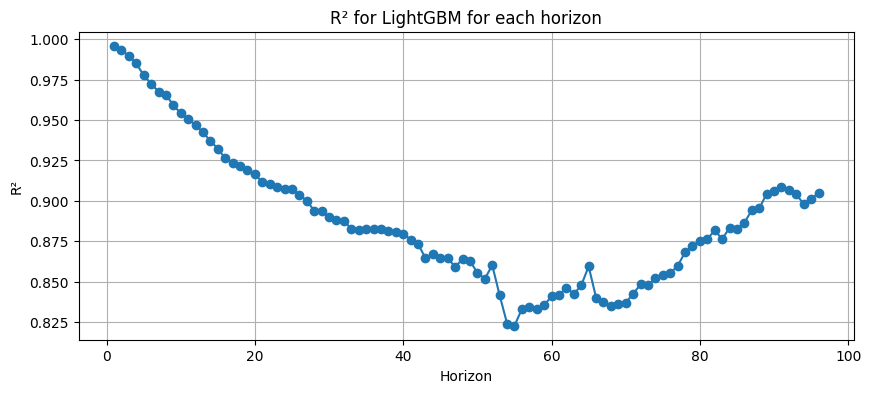

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['R2'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('R²')
plt.title('R² for LightGBM for each horizon')
plt.grid()
plt.show()

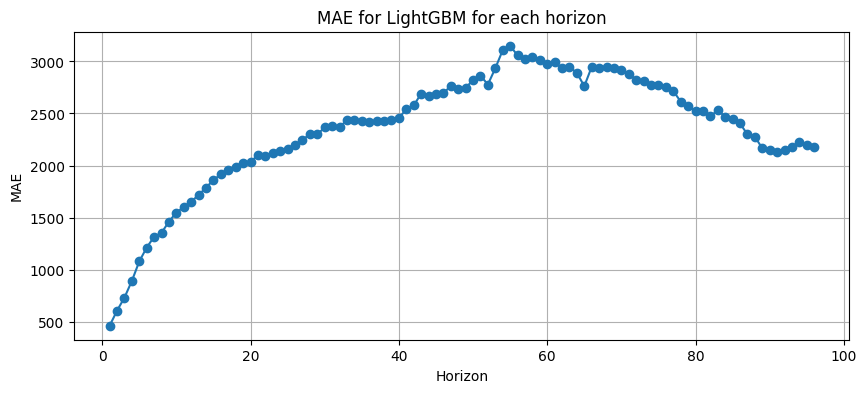

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['MAE'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('MAE')
plt.title('MAE for LightGBM for each horizon')
plt.grid()
plt.show()

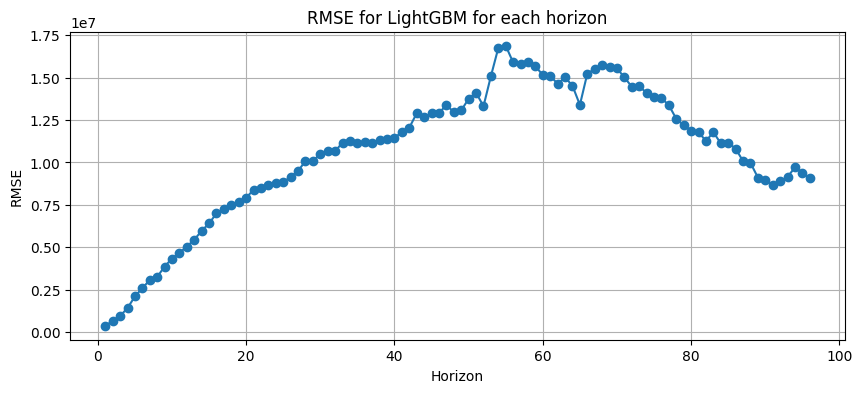

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['RMSE'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('RMSE')
plt.title('RMSE for LightGBM for each horizon')
plt.grid()
plt.show()

In [ ]:
# import lightgbm as lgb

# booster = lgb.Booster(model_file="lgbm_model_RS0.txt")

In [ ]:
# import os
# import lightgbm as lgb
# from tqdm import tqdm

# n_models = 96
# models = []

# for i in tqdm(range(n_models), desc="Download models"):
#     path = f"lgbm_model_RS{i}.txt"
#     if os.path.exists(path):
#         booster = lgb.Booster(model_file=path)
#         models.append(booster)
#     else:
#         print(f"⚠️  Model {path} not found — skip].")

Download models: 100%|██████████| 672/672 [00:02<00:00, 245.84it/s]

⚠️  Model lgbm_model_RS96.txt not found — skip].
⚠️  Model lgbm_model_RS97.txt not found — skip].
⚠️  Model lgbm_model_RS98.txt not found — skip].
⚠️  Model lgbm_model_RS99.txt not found — skip].
⚠️  Model lgbm_model_RS100.txt not found — skip].
⚠️  Model lgbm_model_RS101.txt not found — skip].
⚠️  Model lgbm_model_RS102.txt not found — skip].
⚠️  Model lgbm_model_RS103.txt not found — skip].
⚠️  Model lgbm_model_RS104.txt not found — skip].
⚠️  Model lgbm_model_RS105.txt not found — skip].
⚠️  Model lgbm_model_RS106.txt not found — skip].
⚠️  Model lgbm_model_RS107.txt not found — skip].
⚠️  Model lgbm_model_RS108.txt not found — skip].
⚠️  Model lgbm_model_RS109.txt not found — skip].
⚠️  Model lgbm_model_RS110.txt not found — skip].
⚠️  Model lgbm_model_RS111.txt not found — skip].
⚠️  Model lgbm_model_RS112.txt not found — skip].
⚠️  Model lgbm_model_RS113.txt not found — skip].
⚠️  Model lgbm_model_RS114.txt not found — skip].
⚠️  Model lgbm_model_RS115.txt not found — skip].
⚠️  

In [ ]:
%time models[0].predict(X_test)

CPU times: user 619 ms, sys: 16.5 ms, total: 635 ms
Wall time: 1.16 s


array([68342.32340108, 68771.6585382 , 68320.78492748, ...,
       44627.13919964, 44408.43520785, 43682.72592542])

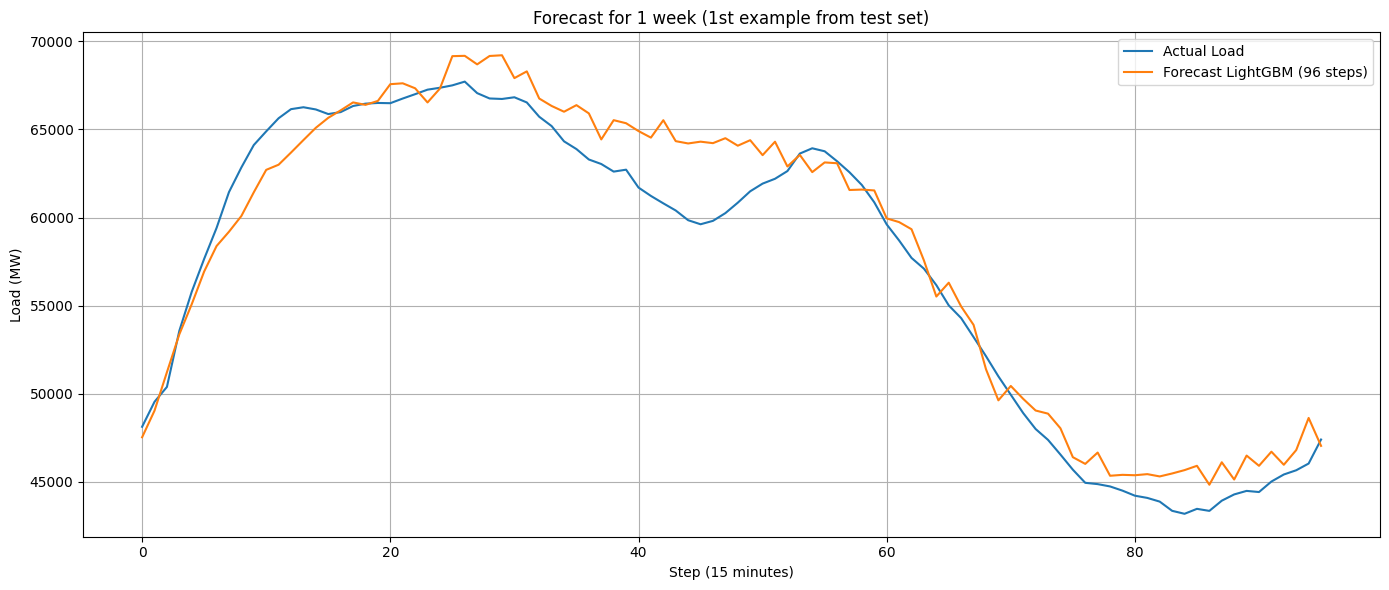

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 6))
# plt.plot(y_test[:min_len][0], label='Actual Load')
# plt.plot(y_pred[:min_len][0], label='Forecast LightGBM (96 steps)')
# plt.title('Forecast for 1 day (1st example from test set)')
# plt.xlabel('Step (15 minutes)')
# plt.ylabel('Load (MW)')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

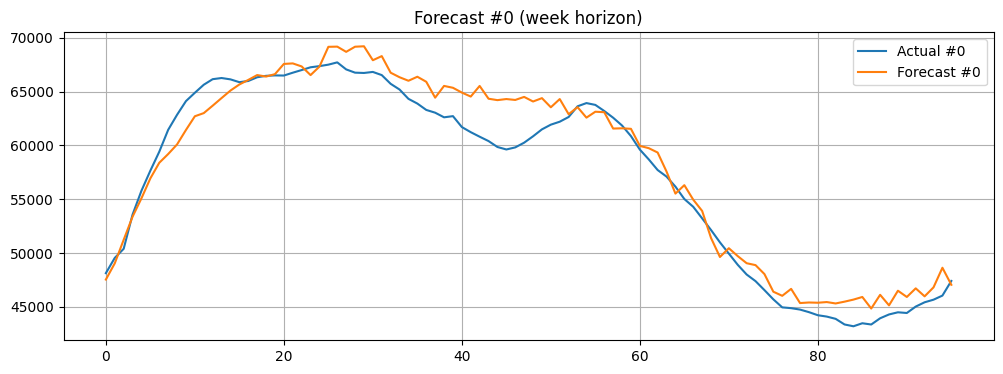

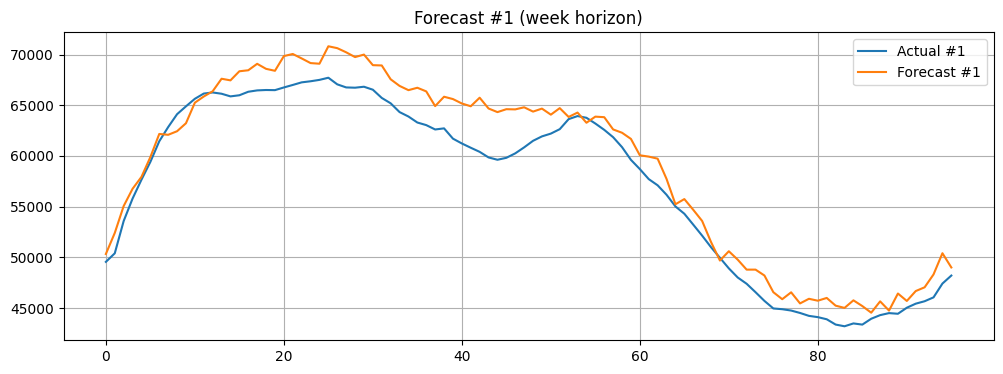

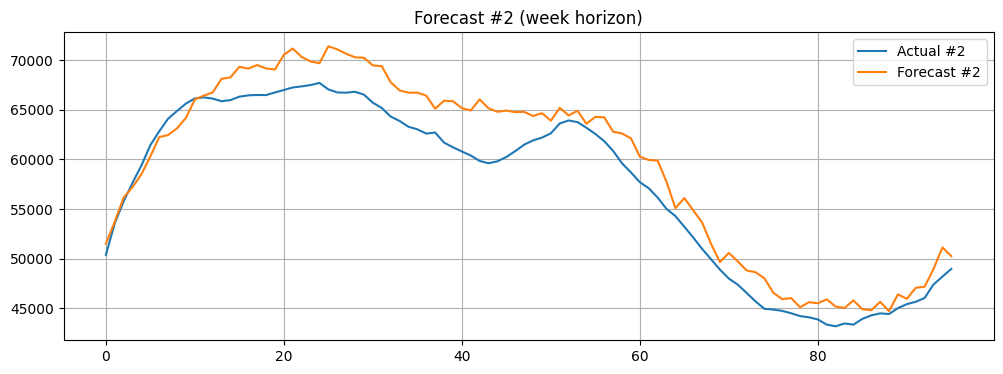

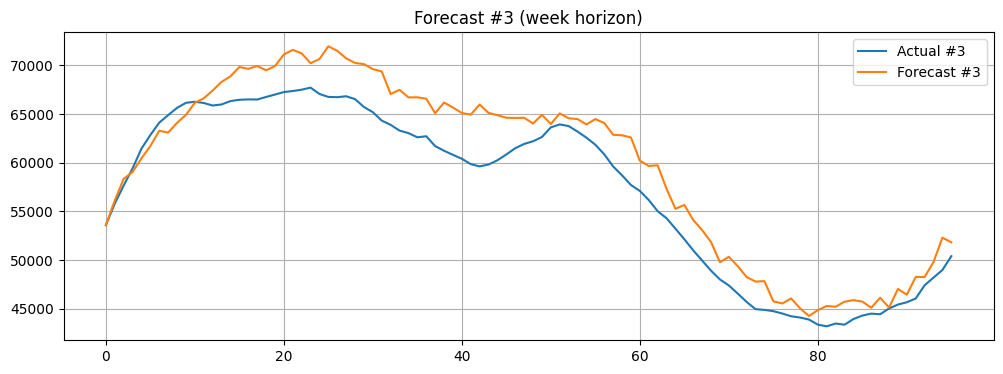

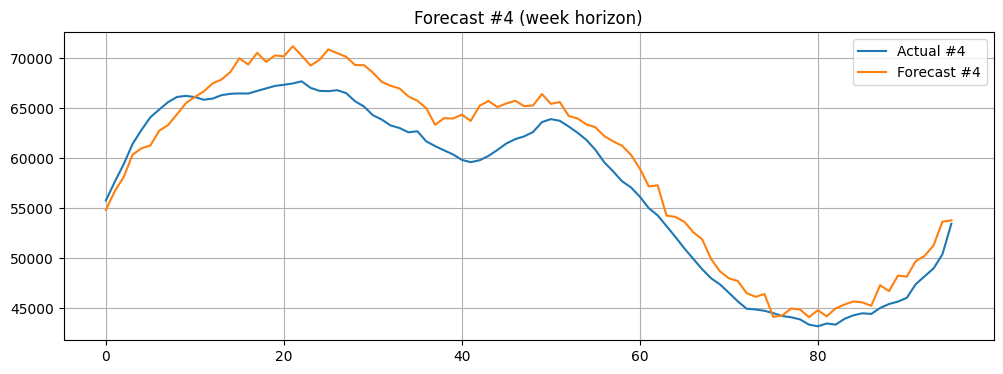

In [ ]:
# for i in range(5):
#     plt.figure(figsize=(12, 4))
#     plt.plot(y_test[i], label=f'Actual #{i}')
#     plt.plot(y_pred[i], label=f'Forecast #{i}')
#     plt.title(f'Forecast #{i} (week horizon)')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# CatBoost

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone
from joblib import Parallel, delayed
from tqdm import tqdm


param_dist = {
    'iterations': [200, 300, 400, 500],
    'learning_rate': [0.05],
    'depth': [4, 6, 8, 10],
    'subsample': [0.6, 0.8, 1.0],
    'l2_leaf_reg': [1, 3, 5, 7],
    'random_strength': [0.5, 1, 3],
    'bagging_temperature': [0, 1, 5],
}


base_model = CatBoostRegressor(
    learning_rate=0.05,
    random_seed=42,
    verbose=0,
    thread_count=1,
    loss_function='RMSE'
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train[:, 0])


best_params = random_search.best_params_
print("Best hyperparameters:", best_params)


final_model = CatBoostRegressor(
    random_seed=42,
    verbose=0,
    thread_count=1,
    loss_function='RMSE',
    **best_params
)


def train_one(i):
    model = clone(final_model)
    model.fit(X_train, y_train[:, i])
    return model


models = Parallel(n_jobs=-1)(
    delayed(train_one)(i) for i in tqdm(range(y_train.shape[1]), desc="Training CatBoost")
)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best hyperparameters: {'subsample': 1.0, 'random_strength': 0.5, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 400, 'depth': 8, 'bagging_temperature': 0}


Training CatBoost: 100%|██████████| 96/96 [20:43<00:00, 12.96s/it]


In [ ]:
for i, model in enumerate(models):
    model.save_model(f"catboost_model_{i}.cbm", format="cbm")

In [ ]:

models = []
for i in range(y_test.shape[1]):
    model = CatBoostRegressor()
    model.load_model(f"catboost_model_{i}.cbm", format="cbm")
    models.append(model)

In [ ]:

y_pred = np.column_stack([
    model.predict(X_test) for model in tqdm(models, desc="Predicting")
])

Predicting: 100%|██████████| 96/96 [00:01<00:00, 72.49it/s]


In [ ]:

r2_list, rmse_list, mae_list = [], [], []

for i in range(y_test.shape[1]):
    y_true = y_test[:, i]
    y_hat = y_pred[:, i]

    r2_list.append(r2_score(y_true, y_hat))
    rmse_list.append(mean_squared_error(y_true, y_hat))
    mae_list.append(mean_absolute_error(y_true, y_hat))

metrics_df = pd.DataFrame({
    'horizon': np.arange(1, y_test.shape[1] + 1),
    'R2': r2_list,
    'RMSE': rmse_list,
    'MAE': mae_list
})
print(metrics_df.tail(10))

    horizon        R2          RMSE          MAE
86       87  0.906666  8.887846e+06  2163.825386
87       88  0.906617  8.891990e+06  2155.495604
88       89  0.910024  8.567272e+06  2105.186571
89       90  0.910102  8.559549e+06  2103.566020
90       91  0.914782  8.113882e+06  2037.611328
91       92  0.914811  8.111000e+06  2031.159824
92       93  0.914038  8.184773e+06  2047.520077
93       94  0.915030  8.090669e+06  2021.857657
94       95  0.912480  8.333772e+06  2051.264679
95       96  0.915337  8.062214e+06  2010.666245


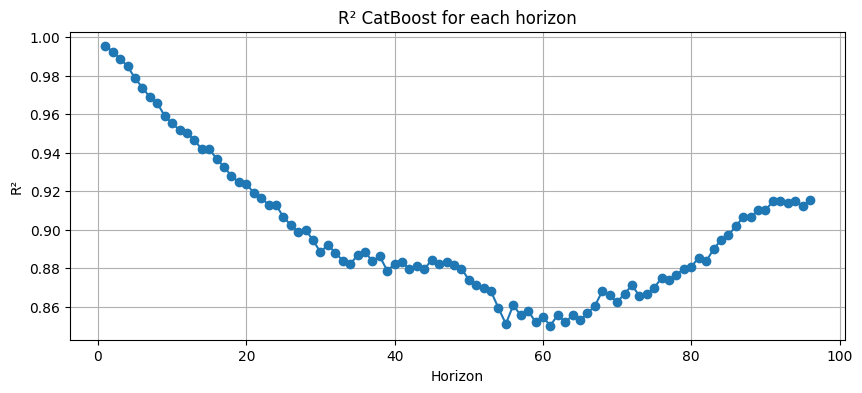

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['R2'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('R²')
plt.title('R² CatBoost for each horizon')
plt.grid()
plt.show()

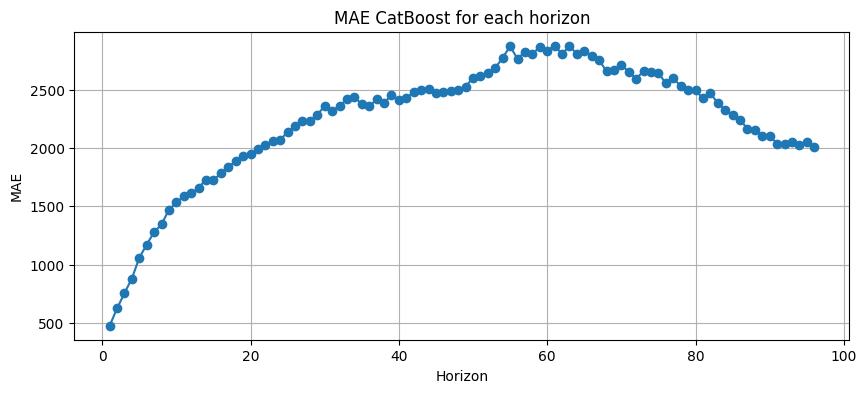

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['MAE'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('MAE')
plt.title('MAE CatBoost for each horizon')
plt.grid()
plt.show()

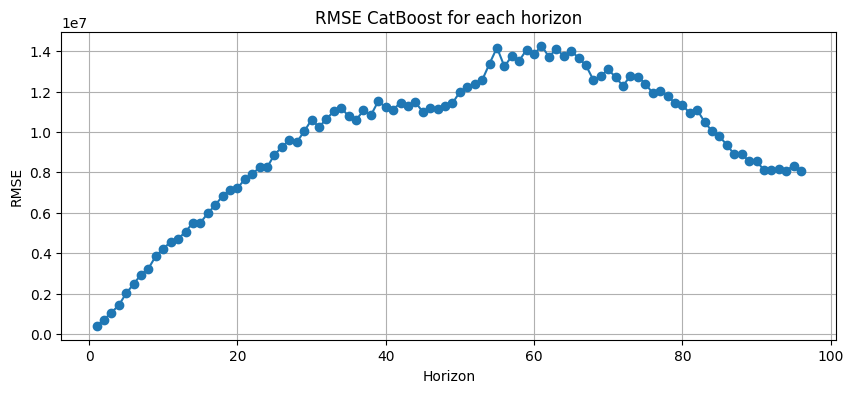

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df['horizon'], metrics_df['RMSE'], marker='o')
plt.xlabel('Horizon')
plt.ylabel('RMSE')
plt.title('RMSE CatBoost for each horizon')
plt.grid()
plt.show()

In [ ]:
import os
from catboost import CatBoostRegressor
from tqdm import tqdm

n_models = 96
models = []

for i in tqdm(range(n_models), desc="Dowmnload models"):
    path = f"catboost_model_{i}.cbm"
    if os.path.exists(path):
        model = CatBoostRegressor()
        model.load_model(path)
        models.append(model)
    else:
        print(f"⚠️  Модель {path} not found - skip.")

Dowmnload models: 100%|██████████| 96/96 [00:00<00:00, 131.88it/s]


In [ ]:
import numpy as np


all_importances = np.array([
    model.get_feature_importance(type='FeatureImportance')
    for model in models
])

mean_importances = all_importances.mean(axis=0)

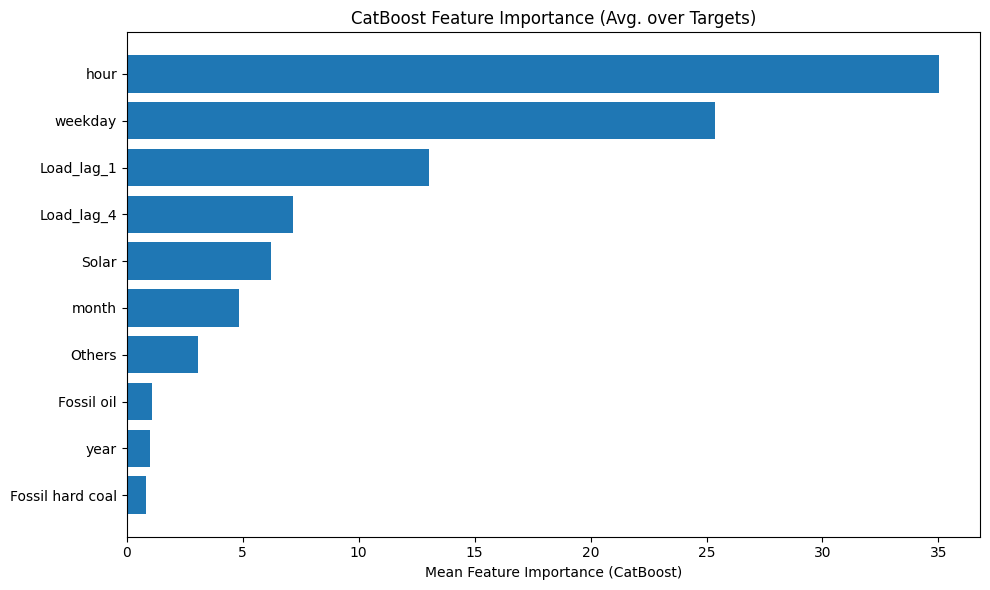

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['feature'].head(10)[::-1],
    importance_df['importance'].head(10)[::-1]
)
plt.xlabel('Mean Feature Importance (CatBoost)')
plt.title('CatBoost Feature Importance (Avg. over Targets)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred = np.column_stack([model.predict(X_test) for model in models])


print("Shape y_test:", y_test.shape)
print("Shape y_pred:", y_pred.shape)


min_len = min(y_test.shape[0], y_pred.shape[0])
y_test_eval = y_test[:min_len]
y_pred_eval = y_pred[:min_len]


mae = mean_absolute_error(y_test_eval, y_pred_eval)
rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
r2 = r2_score(y_test_eval, y_pred_eval)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

Shape y_test: (18701, 96)
Shape y_pred: (18701, 96)
MAE: 2238.6
RMSE: 3110.62
R²: 0.8983


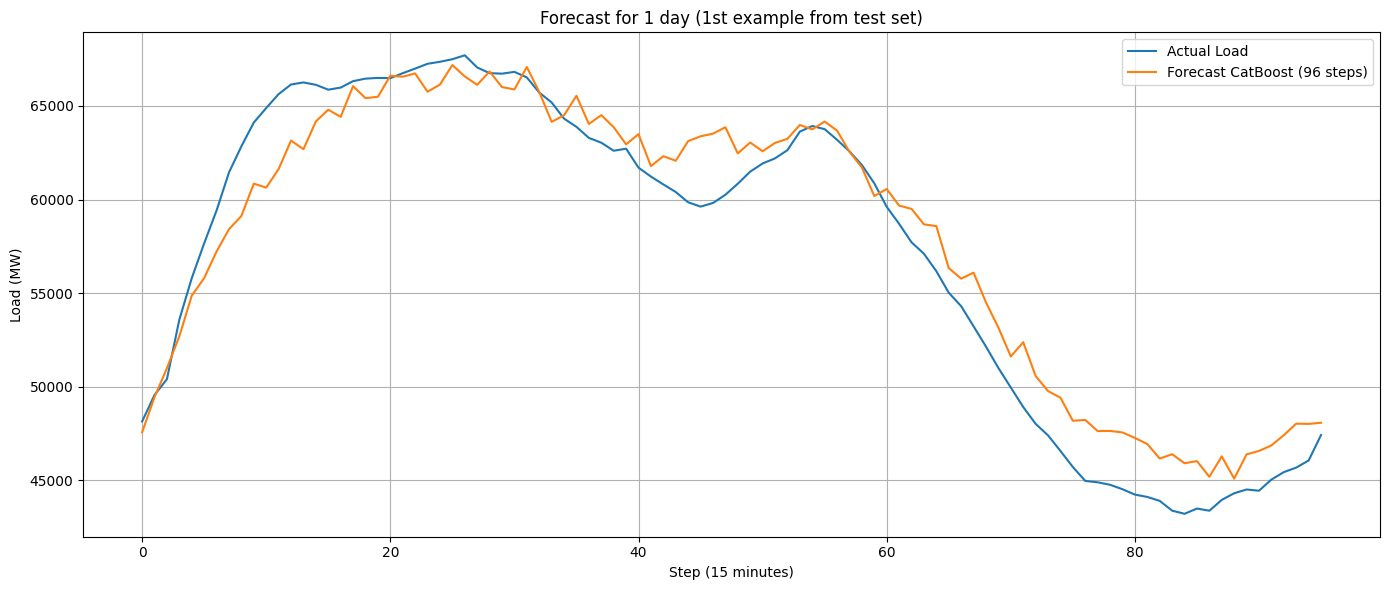

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_test[:min_len][0], label='Actual Load')
plt.plot(y_pred[:min_len][0], label='Forecast CatBoost (96 steps)')
plt.title('Forecast for 1 day (1st example from test set)')
plt.xlabel('Step (15 minutes)')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Total comparison

In [ ]:
from xgboost import XGBRegressor

xgb_models = []
for i in range(96):
    model = XGBRegressor()
    model.load_model(f"xgb_model_RS{i}.json")
    xgb_models.append(model)

# preds
xgb_fcst = np.column_stack([model.predict(X_test) for model in xgb_models])

In [ ]:
import lightgbm as lgb

lgbm_models = []
for i in range(96):
    model = lgb.Booster(model_file=f"lgbm_model_RS{i}.txt")
    lgbm_models.append(model)

# preds
lgbm_fcst = np.column_stack([model.predict(X_test) for model in lgbm_models])

In [ ]:
from catboost import CatBoostRegressor

cat_models = []
for i in range(96):
    model = CatBoostRegressor()
    model.load_model(f"catboost_model_{i}.cbm")
    cat_models.append(model)

# preds
cat_fcst = np.column_stack([model.predict(X_test) for model in cat_models])

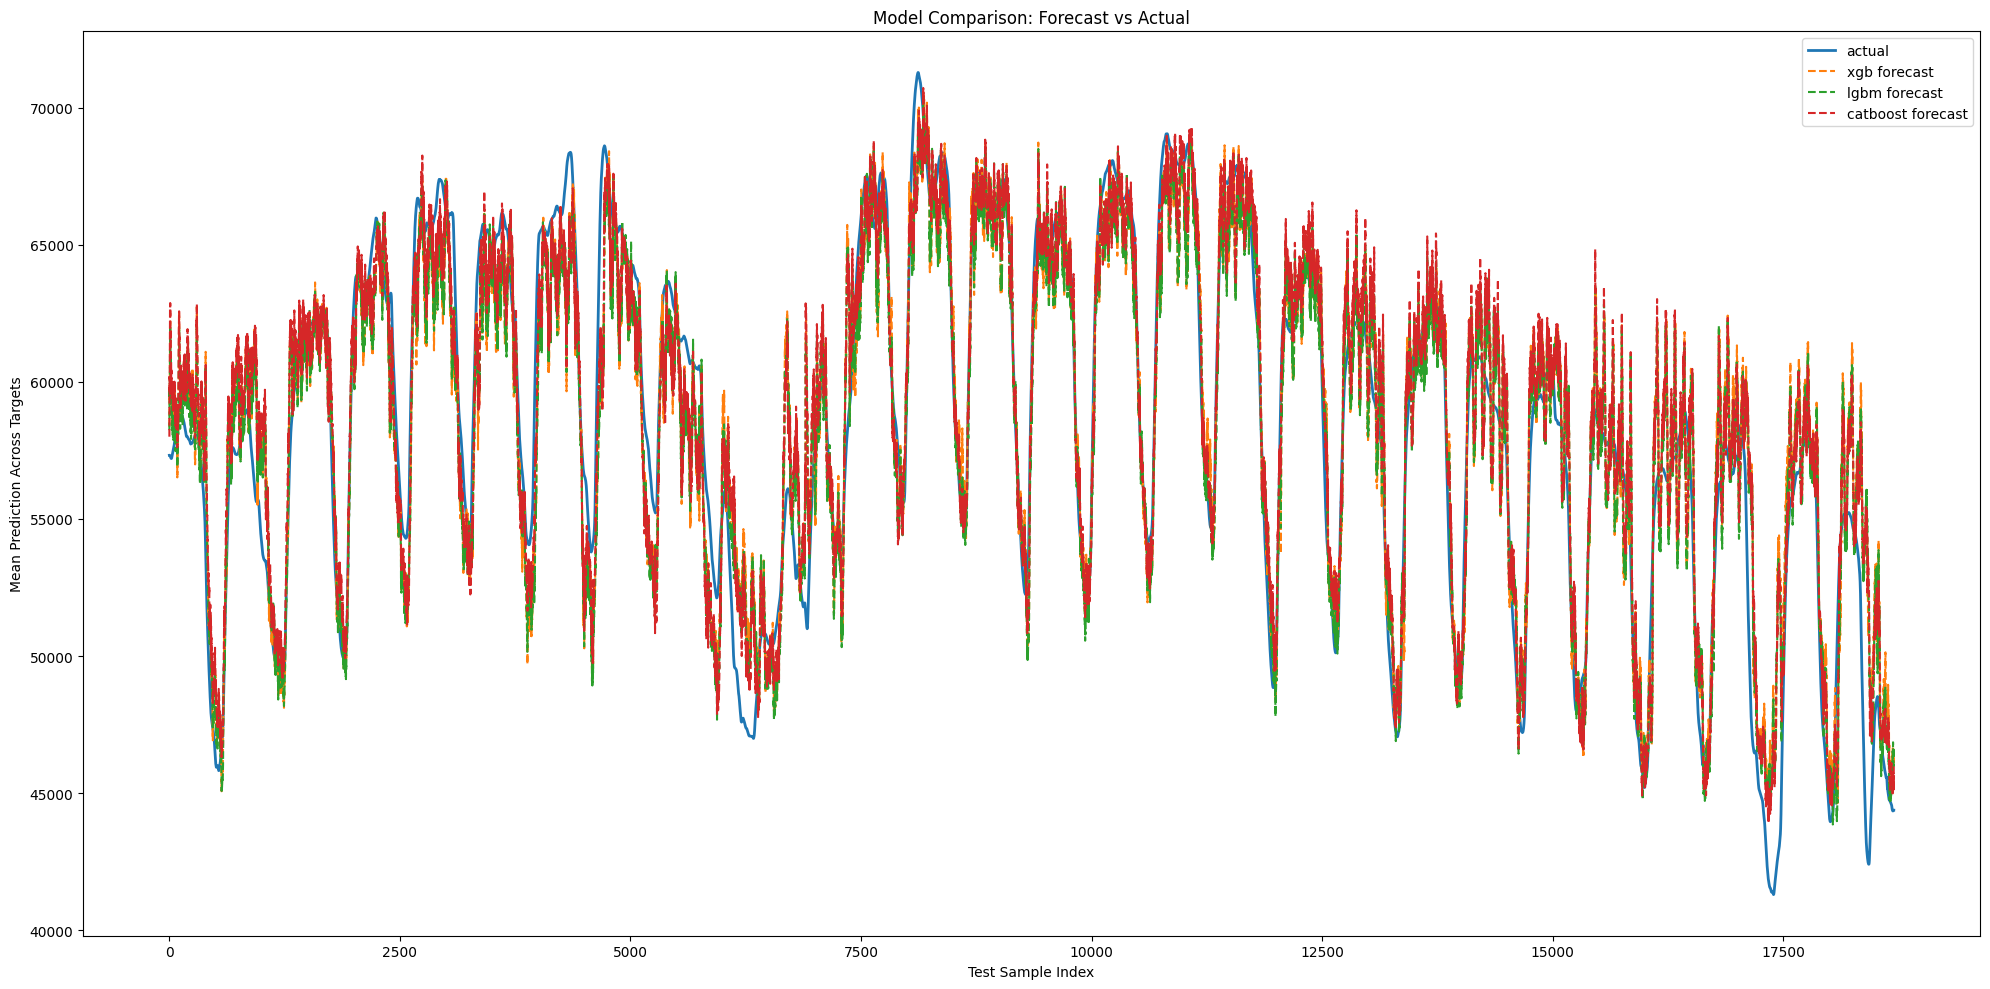

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Average by all 96
y_test_mean = y_test.mean(axis=1)
xgb_fcst_mean = xgb_fcst.mean(axis=1)
lgbm_fcst_mean = lgbm_fcst.mean(axis=1)
cat_fcst_mean = cat_fcst.mean(axis=1)

plt.figure(figsize=(20, 10))
plt.plot(y_test_mean, label='actual', linewidth=2)
plt.plot(xgb_fcst_mean, label='xgb forecast', linestyle='--')
plt.plot(lgbm_fcst_mean, label='lgbm forecast', linestyle='--')
plt.plot(cat_fcst_mean, label='catboost forecast', linestyle='--')
plt.legend()
plt.ylabel('Mean Prediction Across Targets')
plt.xlabel('Test Sample Index')
plt.title('Model Comparison: Forecast vs Actual')
plt.tight_layout()
plt.show()